# KIQ 2.2 — Brand mention share across subreddits

**Question:** What is each smart-glasses brand's share of mentions on Reddit (proxy for share of voice)?

**Pipeline:**
1. Filter to `kiq_label == 'KIQ_2_2'`.
2. Pre-filter comments to those that contain at least one brand keyword (a no-brand comment cannot
   contribute to share of voice).
3. LLM (`gemma4-q6` via Ollama) judges substantive brand-relevance and scores sentiment.
4. Keyword-based brand detection identifies which brand(s) each item mentions; the LLM result is
   an *overall* sentiment for the item, not per-brand.

**Caveat:** the per-brand sentiment column is the average overall-sentiment of items that mention
the brand. It does NOT isolate sentiment toward a single brand within a multi-brand comparison.

## Setup

In [1]:
import sys
from pathlib import Path

# Allow `import analysis_utils` and `import llm_utils` from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from analysis_utils import (
    BRAND_KEYWORDS,
    detect_brands,
    explode_brands,
    has_any_brand,
    sentiment_distribution,
    weekly_volume_and_sentiment,
    monthly_volume_and_sentiment,
)
from llm_utils import (
    score_dataframe_with_cache,
    smoke_test,
    DEFAULT_MODEL,
    KIQ_TOPICS,
)

POSTS_PATH = ROOT / "data" / "processed" / "reddit_posts_clean.csv"
COMMENTS_PATH = ROOT / "data" / "processed" / "reddit_comments_clean.csv"
CACHE_DIR = ROOT / "data" / "llm_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
OUT_DIR = ROOT / 'outputs' / 'kiq_2_2'
OUT_DIR.mkdir(parents=True, exist_ok=True)
KIQ = 'KIQ_2_2'

## Load + filter + brand pre-filter on comments

In [3]:
posts = pd.read_csv(POSTS_PATH)
comments = pd.read_csv(COMMENTS_PATH)
posts['_llm_text'] = (
    posts['title'].fillna('').astype(str) + ' ' + posts['text'].fillna('').astype(str)
).str.strip()
comments['_llm_text'] = comments['body'].fillna('').astype(str)

posts_k = posts[(posts['kiq_label'] == KIQ) & (posts['_llm_text'].str.len() > 0)].copy()
comments_k = comments[(comments['kiq_label'] == KIQ) & (comments['_llm_text'].str.len() > 0)].copy()

# Brand-keyword pre-filter on comments only (posts already retrieved by brand-themed queries).
comments_k = comments_k[comments_k['_llm_text'].apply(has_any_brand)].copy()

print(f'Posts (KIQ_2_2):              {len(posts_k):>6}')
print(f'Comments (KIQ_2_2, brand-pre-filtered): {len(comments_k):>6}')
print(f'Estimated first-run LLM time at 4s/call: ~{(len(posts_k)+len(comments_k))*4/60:.0f} minutes')

Posts (KIQ_2_2):                1077
Comments (KIQ_2_2, brand-pre-filtered):   3692
Estimated first-run LLM time at 4s/call: ~318 minutes


## LLM scoring (relevance + sentiment)

Each post and comment is sent to Ollama (`gemma4-q6:latest`, `think=false`).
The model returns `is_relevant`, `sentiment_label`, `sentiment_score`, and a brief `reason`.
Results are cached to `data/llm_cache/` by item id, so re-running this cell is instant after the first pass.

In [4]:
# Pre-flight: confirm Ollama + model are reachable BEFORE we start a long run.
import time
t0 = time.time()
_check = smoke_test()
print(f"Ollama OK ({DEFAULT_MODEL}) — single-call latency: {time.time()-t0:.1f}s")
print(f"  sample result: {_check}")


Ollama OK (gemma4-q6:latest) — single-call latency: 3.7s
  sample result: {'is_relevant': True, 'sentiment_label': 'negative', 'sentiment_score': -0.8, 'reason': "The comment directly discusses Meta's facial recognition feature and expresses strong negative concerns about privacy."}


In [5]:
posts_scored = score_dataframe_with_cache(
    posts_k,
    text_col='_llm_text',
    id_col='post_id',
    cache_path=CACHE_DIR / 'kiq_2_2_posts.csv',
    kiq='KIQ_2_2',
    kind='post',
)
comments_scored = score_dataframe_with_cache(
    comments_k,
    text_col='_llm_text',
    id_col='comment_id',
    cache_path=CACHE_DIR / 'kiq_2_2_comments.csv',
    kiq='KIQ_2_2',
    kind='comment',
)
posts_scored[['post_id', 'subreddit', 'is_relevant', 'sentiment_label', 'sentiment_score']].head()

[KIQ_2_2/post] cached: 0, to score: 1077 of 1077


KIQ_2_2/post: 100%|██████████| 1077/1077 [1:08:18<00:00,  3.81s/it]


[KIQ_2_2/comment] cached: 0, to score: 3692 of 3692


KIQ_2_2/comment: 100%|██████████| 3692/3692 [3:32:07<00:00,  3.45s/it]  


,post_id,subreddit,is_relevant,sentiment_label,sentiment_score
0,1k294rg,technology,True,positive,0.6
1,1k639m4,technology,True,positive,0.7
2,1l2jg4i,technology,True,negative,-0.5
3,1lx92ve,technology,True,neutral,0.0
4,1mdopv8,technology,True,positive,0.7


## Apply LLM relevance filter

Drop items the model judged off-topic. The dropped sets are written to
`outputs/kiq_2_2/kiq_2_2_dropped_*.csv` for spot-checking.

In [6]:
posts_before = len(posts_scored); comments_before = len(comments_scored)
posts_dropped = posts_scored[posts_scored['is_relevant'] == False].copy()
comments_dropped = comments_scored[comments_scored['is_relevant'] == False].copy()
posts_scored = posts_scored[posts_scored['is_relevant'] == True].copy()
comments_scored = comments_scored[comments_scored['is_relevant'] == True].copy()

filter_log = pd.DataFrame([
    {'slice': 'posts',    'n_before': posts_before,    'n_after': len(posts_scored)},
    {'slice': 'comments', 'n_before': comments_before, 'n_after': len(comments_scored)},
])
print(f'Posts:    {posts_before:>5} -> {len(posts_scored):>5} after LLM relevance filter')
print(f'Comments: {comments_before:>5} -> {len(comments_scored):>5} after LLM relevance filter')
filter_log

Posts:     1077 ->   936 after LLM relevance filter
Comments:  3692 ->  2312 after LLM relevance filter


,slice,n_before,n_after
0,posts,1077,936
1,comments,3692,2312


## Re-detect brands on the filtered set

In [7]:
# Posts already have a 'brand' column from label_kiq.py, but recompute on the LLM-relevant subset
# so the brand text matches what the LLM saw.
posts_scored['brand'] = posts_scored['_llm_text'].map(detect_brands)
comments_scored['brand'] = comments_scored['_llm_text'].map(detect_brands)
comments_scored['brand'].value_counts().head(10)

brand
meta                 790
xreal                790
apple                200
meta,apple           124
google               104
meta,google           52
google,xreal          49
meta,xreal            28
apple,xreal           25
meta,apple,google     24
Name: count, dtype: int64

## Brand share of voice

In [8]:
brand_posts = explode_brands(posts_scored, brand_col='brand')
brand_comments = explode_brands(comments_scored, brand_col='brand')

share = pd.DataFrame({
    'n_posts': brand_posts['brand'].value_counts(),
    'n_comments': brand_comments['brand'].value_counts(),
}).fillna(0).astype(int)
share['share_pct_posts']    = share['n_posts']    / share['n_posts'].sum()    * 100
share['share_pct_comments'] = share['n_comments'] / share['n_comments'].sum() * 100
share = share.sort_values('n_comments', ascending=False)
share.round(2)

,n_posts,n_comments,share_pct_posts,share_pct_comments
brand,,,,
meta,532,1071,44.56,38.55
xreal,402,923,33.67,33.23
apple,127,419,10.64,15.08
google,75,273,6.28,9.83
snap,37,64,3.10,2.30
xiaomi,21,28,1.76,1.01


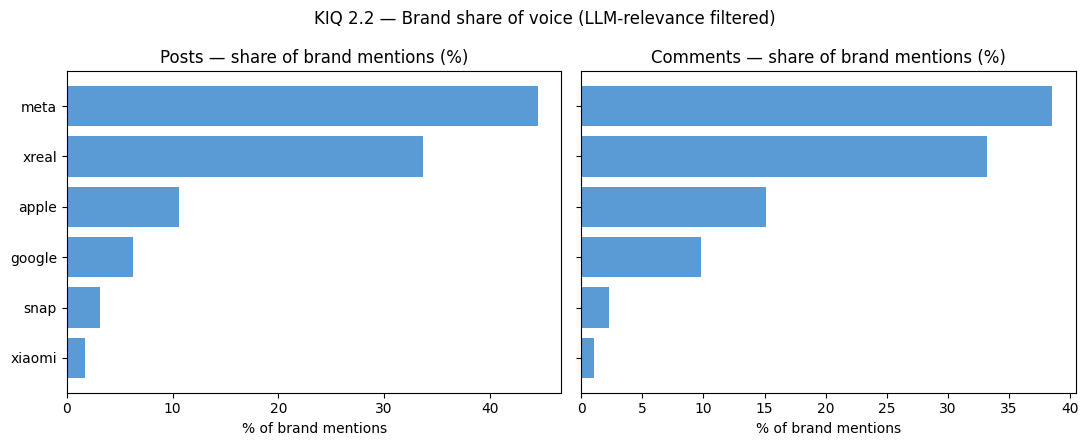

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=100, sharey=True)
for ax, col, title in [
    (axes[0], 'share_pct_posts', 'Posts'),
    (axes[1], 'share_pct_comments', 'Comments'),
]:
    s = share[col].sort_values()
    ax.barh(s.index, s.values, color='#5b9bd5')
    ax.set_title(f'{title} — share of brand mentions (%)')
    ax.set_xlabel('% of brand mentions')
fig.suptitle('KIQ 2.2 — Brand share of voice (LLM-relevance filtered)')
fig.tight_layout()
fig.savefig(OUT_DIR / 'kiq_2_2_share.png', dpi=300)
plt.show()

## Brand × subreddit

In [10]:
brand_sub = (brand_comments.groupby(['subreddit', 'brand']).size()
             .rename('n').reset_index())
top_subs = (brand_sub.groupby('subreddit')['n'].sum()
            .sort_values(ascending=False).head(8).index.tolist())
matrix = (brand_sub[brand_sub['subreddit'].isin(top_subs)]
          .pivot(index='subreddit', columns='brand', values='n')
          .reindex(top_subs).fillna(0))
matrix

brand,apple,google,meta,snap,xiaomi,xreal
subreddit,,,,,,
augmentedreality,85.0,83.0,256.0,38.0,13.0,267.0
Xreal,25.0,26.0,11.0,2.0,1.0,602.0
RaybanMeta,30.0,30.0,377.0,8.0,9.0,0.0
apple,199.0,41.0,143.0,8.0,0.0,6.0
SmartGlasses,11.0,21.0,100.0,3.0,5.0,28.0
gadgets,45.0,9.0,31.0,0.0,0.0,11.0
technology,9.0,9.0,60.0,1.0,0.0,1.0
Futurology,4.0,23.0,44.0,2.0,0.0,1.0


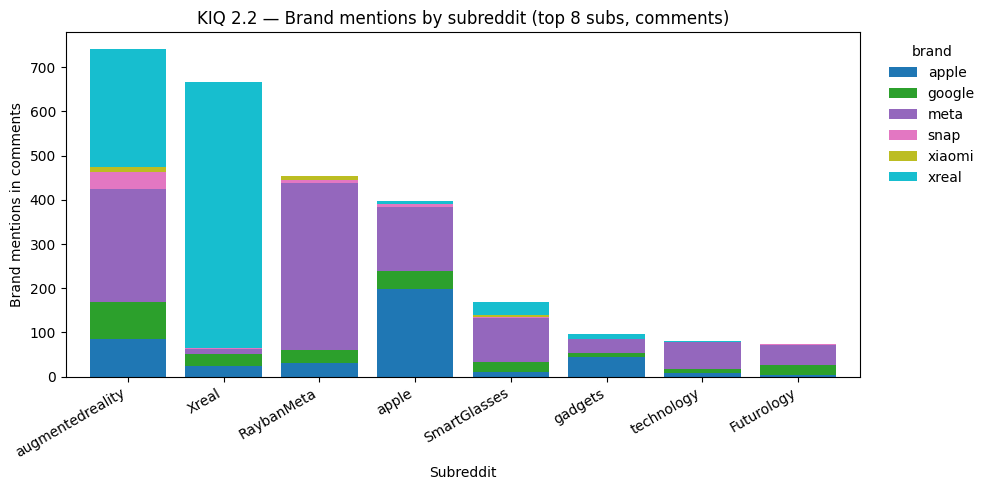

In [11]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
matrix.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.8)
ax.set_ylabel('Brand mentions in comments')
ax.set_xlabel('Subreddit')
ax.set_title('KIQ 2.2 — Brand mentions by subreddit (top 8 subs, comments)')
ax.legend(title='brand', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.xticks(rotation=30, ha='right')
fig.tight_layout()
fig.savefig(OUT_DIR / 'kiq_2_2_by_subreddit.png', dpi=300)
plt.show()

## Sentiment per brand (overall-sentiment of items that mention the brand)

In [12]:
brand_sent = pd.concat([
    brand_posts[['brand', 'sentiment_score', 'sentiment_label']].assign(_kind='post'),
    brand_comments[['brand', 'sentiment_score', 'sentiment_label']].assign(_kind='comment'),
], ignore_index=True)
per_brand = brand_sent.groupby('brand').agg(
    n=('sentiment_score', 'size'),
    mean_score=('sentiment_score', 'mean'),
    pct_positive=('sentiment_label', lambda s: (s == 'positive').mean() * 100),
    pct_negative=('sentiment_label', lambda s: (s == 'negative').mean() * 100),
).sort_values('mean_score', ascending=False)
per_brand.round(3)

,n,mean_score,pct_positive,pct_negative
brand,,,,
xiaomi,49,0.185714,26.531,6.122
snap,101,0.184158,29.703,14.851
xreal,1325,0.118189,21.811,15.094
google,348,0.089655,22.701,20.115
apple,546,0.058059,24.176,29.304
meta,1603,0.050905,24.641,28.197


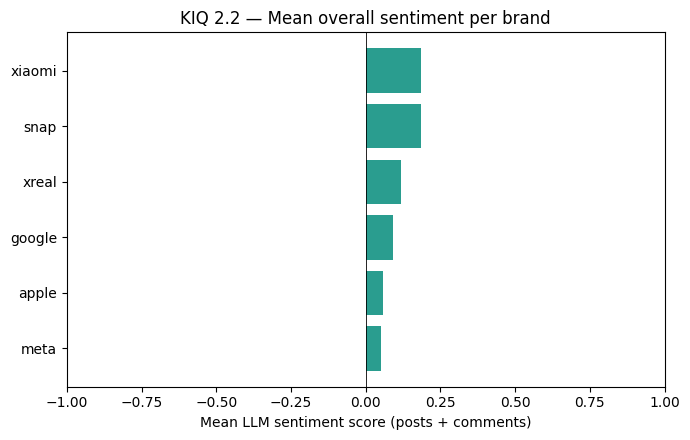

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=100)
colors_bar = ['#e76f51' if v < 0 else '#2a9d8f' for v in per_brand['mean_score']]
ax.barh(per_brand.index[::-1], per_brand['mean_score'].values[::-1], color=colors_bar[::-1])
ax.axvline(0, color='black', lw=0.6)
ax.set_xlim(-1, 1)
ax.set_xlabel('Mean LLM sentiment score (posts + comments)')
ax.set_title('KIQ 2.2 — Mean overall sentiment per brand')
fig.tight_layout()
fig.savefig(OUT_DIR / 'kiq_2_2_sentiment_per_brand.png', dpi=300)
plt.show()

## Write outputs

In [14]:
posts_scored.to_csv(OUT_DIR / 'kiq_2_2_scored_posts.csv', index=False)
comments_scored.to_csv(OUT_DIR / 'kiq_2_2_scored_comments.csv', index=False)
share.to_csv(OUT_DIR / 'kiq_2_2_brand_share.csv')
brand_sub.to_csv(OUT_DIR / 'kiq_2_2_brand_subreddit.csv', index=False)
per_brand.to_csv(OUT_DIR / 'kiq_2_2_sentiment_per_brand.csv')
filter_log.to_csv(OUT_DIR / 'kiq_2_2_filter_log.csv', index=False)
posts_dropped.to_csv(OUT_DIR / 'kiq_2_2_dropped_posts.csv', index=False)
comments_dropped.to_csv(OUT_DIR / 'kiq_2_2_dropped_comments.csv', index=False)

print('Wrote outputs to', OUT_DIR)
for f in sorted(OUT_DIR.iterdir()):
    print(' -', f.name)

Wrote outputs to /home/giulio/Uni/Master/SCI/outputs/kiq_2_2
 - kiq_2_2_brand_share.csv
 - kiq_2_2_brand_subreddit.csv
 - kiq_2_2_by_subreddit.png
 - kiq_2_2_dropped_comments.csv
 - kiq_2_2_dropped_posts.csv
 - kiq_2_2_filter_log.csv
 - kiq_2_2_scored_comments.csv
 - kiq_2_2_scored_posts.csv
 - kiq_2_2_sentiment_per_brand.csv
 - kiq_2_2_sentiment_per_brand.png
 - kiq_2_2_share.png
